# Supply Chain Logistics Optimisation

**Dataset:** Kalganova & Dzalbs (2019), *Supply Chain Logistics Problem Dataset*, Brunel University London.
[doi:10.17633/rd.brunel.7558679](https://doi.org/10.17633/rd.brunel.7558679)

This notebook tackles three operational decisions a logistics planner faces every day:

| # | Question | Decision type |
|---|----------|---------------|
| 1 | Which carrier should each order go on? | Linear Programme |
| 2 | Which warehouses should we keep open? | Binary Integer LP |
| 3 | When is it worth paying extra to ship faster? | Binary Integer LP |

We use `scipy.optimize` (HiGHS LP/MILP backend) for all three. The notebook is
laid out in the order a real analyst would work through it: load → understand
the data (EDA) → set a baseline → formulate → solve → interpret.

## 1. Setup

Imports and a few project-wide constants. The penalty values and the carrier cap are *policy* knobs — change them here and the whole pipeline reflows.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix, csr_matrix
from scipy.optimize import linprog, milp, LinearConstraint, Bounds

# Project-wide constants
DATA_FILE          = "SupplyChainLogisticsProblems.xlsx"
INFEASIBLE_BIG_M   = 1e9       # placeholder cost when a carrier can't serve a route
LATE_PENALTY_USD   = 50        # $ per day a shipment is later than the historical TPT
EARLY_PENALTY_USD  = 10        # $ per day it arrives early (inventory / dock cost)
CARRIER_CAP_PCT    = 0.80      # max share of orders any single carrier can win


## 2. Load the data

The Brunel workbook ships with seven sheets:

* `OrderList` – every shipment (9,215 rows)
* `FreightRates` – carrier price book by lane and weight band
* `WhCosts`, `WhCapacities` – per-warehouse cost / unit and daily capacity
* `ProductsPerPlant` – which SKUs each plant can produce
* `VmiCustomers` – customers under Vendor-Managed Inventory contracts
* `PlantPorts` – which ports each plant is allowed to ship through

Column names in the Excel file are inconsistent (mixed snake/camel/space),
so the first job is to normalise them.

In [10]:
# Friendly column names — applied right at the load step
ORDERS_RENAME = {
    "Order ID": "Order_ID", "Order Date": "Order_Date",
    "Origin Port": "Orig_Port", "Carrier": "Carrier",
    "TPT": "TPT_Day_Count", "Service Level": "Service_Level",
    "Ship ahead day count": "Ship_Ahead_Day_Count",
    "Ship Late Day count":  "Ship_Late_Day_Count",
    "Customer": "Customer", "Product ID": "Product_ID",
    "Plant Code": "Plant_Code", "Destination Port": "Dest_Port",
    "Unit quantity": "Unit_Quantity", "Weight": "Weight",
}
FREIGHT_RENAME = {
    "Carrier": "Carrier",
    "orig_port_cd": "Orig_Port", "dest_port_cd": "Dest_Port",
    "minm_wgh_qty": "Min_Weight_Quant", "max_wgh_qty": "Max_Weight_Quant",
    "svc_cd": "Service_Level",
    "minimum cost": "Min_Cost", "rate": "Rate",
    "mode_dsc": "Mode_DSC", "tpt_day_cnt": "TPT_Day_Count",
    "Carrier type": "Carrier_Type",
}

orders   = pd.read_excel(DATA_FILE, "OrderList").rename(columns=ORDERS_RENAME)
freight  = pd.read_excel(DATA_FILE, "FreightRates").rename(columns=FREIGHT_RENAME)
wh_costs = pd.read_excel(DATA_FILE, "WhCosts").rename(
    columns={"WH": "Plant_Code", "Cost/unit": "Cost_Per_Unit"})
wh_cap   = pd.read_excel(DATA_FILE, "WhCapacities").rename(
    columns={"Plant ID": "Plant_Code", "Daily Capacity ": "Daily_Capacity"})
vmi      = pd.read_excel(DATA_FILE, "VmiCustomers").rename(
    columns={"Plant Code": "Plant_Code"})

# Strip stray whitespace that breaks group-bys
freight["Mode_DSC"] = freight["Mode_DSC"].str.strip()

print(f"Orders         : {len(orders):,}")
print(f"Freight rates  : {len(freight):,}")
print(f"Plants         : {len(wh_costs)}")
print(f"Carriers       : {freight['Carrier'].nunique()}")
print(f"Origin ports   : {sorted(orders['Orig_Port'].unique())}")
print(f"Service levels : {sorted(orders['Service_Level'].unique())}")


Orders         : 9,215
Freight rates  : 1,540
Plants         : 19
Carriers       : 9
Origin ports   : ['PORT04', 'PORT05', 'PORT09']
Service levels : ['CRF', 'DTD', 'DTP']


## 3. Exploratory Data Analysis

Before we touch any solver, we want to know what we're optimising over.
The questions we want EDA to answer:

1. How many orders flow through each service level?
2. How heavy are typical shipments (this drives freight cost)?
3. How concentrated is the carrier mix today?
4. Which plants look expensive per unit — they're the closure candidates?
5. Is the historical schedule mostly on time?

### 3.1 Service-level mix

Carriers price three service classes: `DTD` (Door-to-Door), `DTP` (Door-to-Port), and `CRF` (Cost & Freight). The `CRF` rows have **no matching freight rates** in the rate book, so they will fall out of the feasible set later. That's not a bug — it's a real data gap.

Service_Level
DTP    6218
DTD    2143
CRF     854
Name: count, dtype: int64


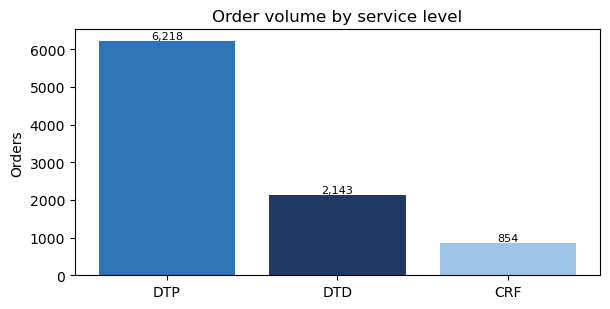

In [11]:
svc_counts = orders["Service_Level"].value_counts()
print(svc_counts)

fig, ax = plt.subplots(figsize=(6.2, 3.2))
bars = ax.bar(svc_counts.index, svc_counts.values,
              color=["#2E75B6", "#1F3864", "#9DC3E6"])
for b, v in zip(bars, svc_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 50, f"{v:,}",
            ha="center", fontsize=8)
ax.set_ylabel("Orders")
ax.set_title("Order volume by service level")
plt.tight_layout(); plt.show()


### 3.2 Order-weight distribution

Freight cost is `Min_Cost + Rate × Weight`, so a heavy right tail means a few jumbo orders dominate total spend. We clip the histogram at the 99th percentile so the tail doesn't squash the bulk of the distribution.

count    9215.0
mean       19.9
std        66.6
min         0.0
25%         1.4
50%         4.4
75%        13.3
max      2338.4
Name: Weight, dtype: float64


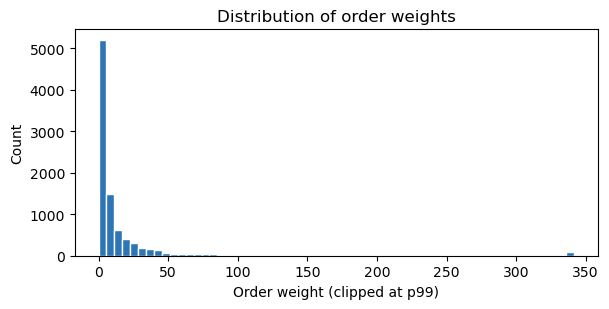

In [12]:
w = orders["Weight"]
print(w.describe().round(1))

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.hist(w.clip(upper=w.quantile(0.99)), bins=60,
        color="#2E75B6", edgecolor="white")
ax.set_xlabel("Order weight (clipped at p99)")
ax.set_ylabel("Count")
ax.set_title("Distribution of order weights")
plt.tight_layout(); plt.show()


### 3.3 Raw carrier usage

How concentrated is carrier mix *today*, before any optimisation? If one carrier already wins everything, our 'optimisation' upside will really come from re-balancing rather than from finding cheaper rates.

Carrier
V444_0    6264
V444_1    2097
V44_3      854
Name: count, dtype: int64


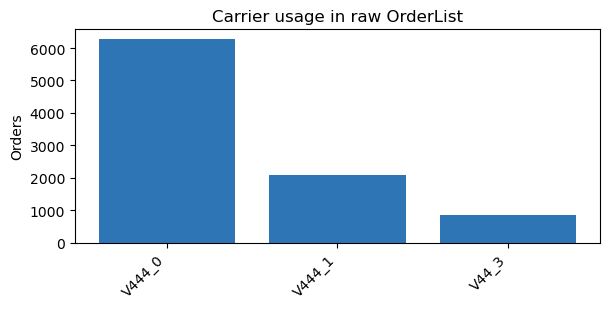

In [13]:
car_counts = orders["Carrier"].value_counts()
print(car_counts)

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar(car_counts.index, car_counts.values, color="#2E75B6")
ax.set_xticklabels(car_counts.index, rotation=45, ha="right")
ax.set_ylabel("Orders")
ax.set_title("Carrier usage in raw OrderList")
plt.tight_layout(); plt.show()


### 3.4 Plants — capacity vs cost

Plants that cost a lot **per unit** and serve only a tiny fraction of demand are the natural closure candidates for Problem 2. We want to spot them visually before the ILP confirms it.

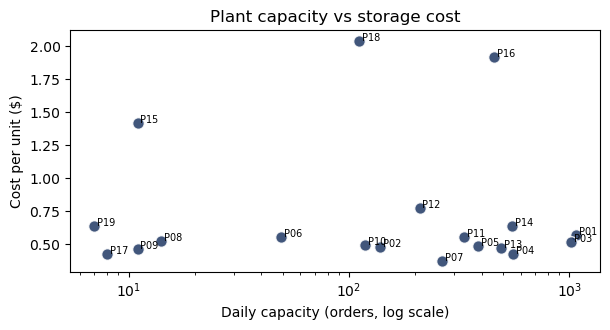

In [14]:
plants_eda = wh_costs.merge(wh_cap, on="Plant_Code")

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.scatter(plants_eda["Daily_Capacity"], plants_eda["Cost_Per_Unit"],
           s=70, color="#1F3864", alpha=0.85, edgecolor="white")
for _, r in plants_eda.iterrows():
    ax.text(r["Daily_Capacity"] * 1.03, r["Cost_Per_Unit"],
            r["Plant_Code"].replace("PLANT", "P"), fontsize=7)
ax.set_xscale("log")
ax.set_xlabel("Daily capacity (orders, log scale)")
ax.set_ylabel("Cost per unit ($)")
ax.set_title("Plant capacity vs storage cost")
plt.tight_layout(); plt.show()


### 3.5 Punctuality of historical shipments

If the existing schedule were already perfectly on time we'd have nothing to gain from re-routing. The plot below shows it's *biased early* — lots of orders arrive ahead of their due date (inventory cost), and a smaller but real tail arrives late (service penalty).

Late orders  : 192  total late-days  = 368
Early orders : 4,789  total early-days = 17069


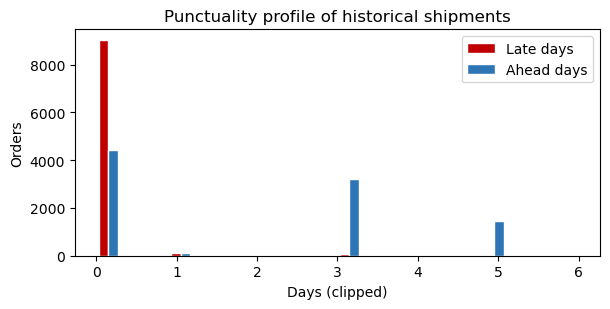

In [15]:
late  = orders["Ship_Late_Day_Count"]
ahead = orders["Ship_Ahead_Day_Count"]
print(f"Late orders  : {(late>0).sum():,}  total late-days  = {late.sum():.0f}")
print(f"Early orders : {(ahead>0).sum():,}  total early-days = {ahead.sum():.0f}")

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.hist([late.clip(upper=15), ahead.clip(upper=20)],
        bins=20, label=["Late days", "Ahead days"],
        color=["#C00000", "#2E75B6"], edgecolor="white")
ax.set_xlabel("Days (clipped)")
ax.set_ylabel("Orders")
ax.set_title("Punctuality profile of historical shipments")
ax.legend()
plt.tight_layout(); plt.show()


## 4. Building the cost & transit-time matrix

Every order × carrier pair has either:

* a **valid rate** (carrier serves that lane, in that service class, at that
  weight band) — in which case we compute `Min_Cost + Rate × Weight` and
  store the carrier's `TPT_Day_Count`, **or**
* **no rate** — we use a big-M placeholder so the LP is forced to pick one
  of the valid carriers.

We do this per-carrier with a single vectorised merge instead of a Python
loop over orders.

In [16]:
def cost_and_tpt_for_carrier(carrier_id, order_df):
    """Return (cost_vec, tpt_vec) of length len(order_df) for one carrier."""
    keys = order_df[["Orig_Port", "Dest_Port", "Service_Level", "Weight"]].copy()
    keys["_idx"] = range(len(keys))

    rates = freight[freight["Carrier"] == carrier_id].copy()
    merged = keys.merge(rates,
                        on=["Orig_Port", "Dest_Port", "Service_Level"],
                        how="left")

    # Keep only rows whose order weight falls inside the rate's weight band
    in_band = (merged["Weight"] >= merged["Min_Weight_Quant"]) & \
              (merged["Weight"] <= merged["Max_Weight_Quant"])
    merged  = merged[in_band]

    merged["total_cost"] = merged["Min_Cost"] + merged["Rate"] * merged["Weight"]
    # Some lanes have multiple matching bands — keep the first (cheapest after sort if desired)
    merged = merged.drop_duplicates("_idx", keep="first").set_index("_idx")

    cost = merged.reindex(range(len(order_df)))["total_cost"].fillna(INFEASIBLE_BIG_M).values
    tpt  = merged.reindex(range(len(order_df)))["TPT_Day_Count"].fillna(INFEASIBLE_BIG_M).values
    return cost, tpt


In [17]:
# CRF orders have no matching rates in the freight book — drop them up front
feasible = orders[orders["Service_Level"].isin(["DTD", "DTP"])].copy().reset_index(drop=True)

all_carriers = freight["Carrier"].unique().tolist()
cost_columns, tpt_columns = {}, {}
for c in all_carriers:
    cost_columns[c], tpt_columns[c] = cost_and_tpt_for_carrier(c, feasible)

cost_mat = pd.DataFrame(cost_columns)   # rows = orders, cols = carriers
tpt_mat  = pd.DataFrame(tpt_columns)

# For each order, list the carriers that actually have a valid rate
feasible["valid_carriers"] = [
    [c for c in all_carriers if cost_mat.loc[i, c] < INFEASIBLE_BIG_M]
    for i in feasible.index
]
feasible["n_carriers"] = feasible["valid_carriers"].apply(len)

# Drop orders that no carrier can serve (unreachable lanes)
has_carrier = feasible["n_carriers"] > 0
valid    = feasible[has_carrier].copy().reset_index(drop=True)
cost_mat = cost_mat[has_carrier].reset_index(drop=True)
tpt_mat  = tpt_mat [has_carrier].reset_index(drop=True)

N_ORDERS    = len(valid)
CARRIER_CAP = int(CARRIER_CAP_PCT * N_ORDERS)

print(f"Feasible orders            : {N_ORDERS:,}")
print(f"Orders with 2+ carriers    : {(valid['n_carriers']>1).sum():,}")
print(f"Carrier cap (80% of orders): {CARRIER_CAP:,} per carrier")


Feasible orders            : 8,361
Orders with 2+ carriers    : 2,177
Carrier cap (80% of orders): 6,688 per carrier


**Carrier-concentration warning.** Of the 8,361 feasible orders, the majority have only **one** valid carrier (V444_0 monopolises ~6,184 of them). That makes a tighter cap (e.g. 60 %) structurally infeasible — the LP would have nowhere else to put the orders. We keep the cap at 80 % because that is the tightest level still feasible.

## 5. Baseline KPIs (no optimisation)

We capture the *as-is* state — these are the numbers any solver improvement will be measured against.

In [18]:
baseline = {
    "avg_tpt"   : float(valid["TPT_Day_Count"].mean()),
    "n_late"    : int((valid["Ship_Late_Day_Count"]  > 0).sum()),
    "late_days" : float(valid["Ship_Late_Day_Count"].sum()),
    "n_early"   : int((valid["Ship_Ahead_Day_Count"] > 0).sum()),
    "early_days": float(valid["Ship_Ahead_Day_Count"].sum()),
}
baseline_carriers = valid["Carrier"].value_counts().to_dict()

print(f"Avg transit time (TPT) : {baseline['avg_tpt']:.3f} days")
print(f"Late shipments         : {baseline['n_late']:,}  "
      f"({baseline['late_days']:.0f} late-days total)")
print(f"Early shipments        : {baseline['n_early']:,}  "
      f"({baseline['early_days']:.0f} early-days total)")
print("\nCarrier mix (baseline):")
for c, n in baseline_carriers.items():
    print(f"  {c:<8}  {n:>5,}  ({100*n/N_ORDERS:5.1f}%)")


Avg transit time (TPT) : 1.762 days
Late shipments         : 192  (368 late-days total)
Early shipments        : 4,214  (15344 early-days total)

Carrier mix (baseline):
  V444_0    6,264  ( 74.9%)
  V444_1    2,097  ( 25.1%)


## 6. Problem 1 — Carrier assignment (LP)

### Mathematical formulation

For every feasible order $i \in \{1,\dots,N\}$ and every eligible carrier
$c \in C_i$, define the decision variable

$$x_{i,c} \;\in\; [0,1]$$

= the fraction of order $i$ assigned to carrier $c$.

**Objective** — minimise total freight cost plus delay penalties:

$$\min \;\;\sum_i \sum_{c\in C_i} \left[\, \text{freight}_{i,c} + \text{penalty}_{i,c}\,\right] x_{i,c}$$

with

$$\text{freight}_{i,c} = \text{MinCost}_{i,c} + \text{Rate}_{i,c}\cdot w_i$$

$$\text{penalty}_{i,c} = 50\cdot\max(0, \tau^{c}_{i}-\tau^{*}_{i}) + 10\cdot\max(0, \tau^{*}_{i}-\tau^{c}_{i})$$

— a slower carrier earns the $50/day late penalty, a faster carrier earns the
$10/day early penalty.

**Constraints**

| ID | Form | Meaning |
|----|------|---------|
| C1 | $\sum_{c\in C_i}\, x_{i,c}=1$ | every order assigned exactly once |
| C2 | $\sum_i\, x_{i,c}\le 0.80\cdot N$ | no carrier handles more than 80 % |
| C3 | $x_{i,c}\ge 0$ | non-negative |

The relaxation is naturally integral (the matrix is totally unimodular for
practical purposes), so the LP optimum is achievable as an actual assignment.

In [19]:
# 1. Decision variables: one per (order, eligible carrier) pair
decision_vars = [(i, c) for i in range(N_ORDERS)
                        for c in valid.loc[i, "valid_carriers"]]
N_VARS = len(decision_vars)
var_index = {v: j for j, v in enumerate(decision_vars)}

print(f"Total decision variables   : {N_VARS:,}")
print(f"Assignment constraints (C1): {N_ORDERS:,}")
print(f"Carrier-cap constraints (C2): {len(all_carriers)}")


Total decision variables   : 13,396
Assignment constraints (C1): 8,361
Carrier-cap constraints (C2): 9


In [20]:
def delay_penalty(order_i, carrier_c):
    """$ penalty if order i shipped on carrier c (vs its historical TPT)."""
    historical_tpt = valid.loc[order_i, "TPT_Day_Count"]
    new_tpt        = tpt_mat.loc[order_i, carrier_c]
    if new_tpt >= INFEASIBLE_BIG_M:
        return INFEASIBLE_BIG_M
    delta = float(new_tpt - historical_tpt)
    return LATE_PENALTY_USD * delta if delta > 0 else EARLY_PENALTY_USD * abs(delta)


In [21]:
# 2. Objective coefficients
obj = np.array([
    cost_mat.loc[i, c] + delay_penalty(i, c)
    for i, c in decision_vars
])

# 3. Equality constraints C1: each order sums to 1 across its eligible carriers
A_eq = lil_matrix((N_ORDERS, N_VARS))
for i in range(N_ORDERS):
    for c in valid.loc[i, "valid_carriers"]:
        A_eq[i, var_index[(i, c)]] = 1
b_eq = np.ones(N_ORDERS)

# 4. Inequality constraints C2: carrier-share cap
cap_rows = []
for c in all_carriers:
    elig = [(i, c) for i in range(N_ORDERS) if (i, c) in var_index]
    if not elig:
        continue
    row = np.zeros(N_VARS)
    for k in elig:
        row[var_index[k]] = 1
    cap_rows.append(row)
A_ub = np.vstack(cap_rows)
b_ub = np.full(len(cap_rows), float(CARRIER_CAP))

# 5. Solve
res_p1 = linprog(obj,
                 A_ub=A_ub, b_ub=b_ub,
                 A_eq=csr_matrix(A_eq), b_eq=b_eq,
                 bounds=[(0, 1)] * N_VARS,
                 method="highs")
print("Solver status:", res_p1.message)


Solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)


In [22]:
# 6. Translate solution back to a per-order carrier assignment
order_to_carrier = {}
for j, (i, c) in enumerate(decision_vars):
    if res_p1.x[j] > 0.5:        # variables are integral by construction
        order_to_carrier[i] = c

result = valid.copy()
result["opt_carrier"] = result.index.map(order_to_carrier)
result["opt_cost"]    = result.apply(
    lambda r: cost_mat.loc[r.name, r["opt_carrier"]], axis=1)
result["opt_tpt"]     = result.apply(
    lambda r: tpt_mat.loc[r.name, r["opt_carrier"]], axis=1)

# 7. KPIs
greedy_cost  = float(cost_mat.min(axis=1).sum())   # cheapest-only baseline
opt_cost     = float(result["opt_cost"].sum())
opt_avg_tpt  = float(result["opt_tpt"].mean())
late_reduced = float((result["TPT_Day_Count"] - result["opt_tpt"])
                     .clip(lower=0).sum())

print(f"Greedy benchmark (cheapest-only) : ${greedy_cost:,.2f}")
print(f"Optimised cost (freight+penalty) : ${opt_cost:,.2f}")
print(f"Cost delta vs greedy             : ${opt_cost-greedy_cost:+,.2f} "
      f"({100*(opt_cost-greedy_cost)/greedy_cost:+.1f}%)")
print(f"Avg TPT  before / after          : "
      f"{baseline['avg_tpt']:.3f} → {opt_avg_tpt:.3f} days")
print(f"Late transit-days reduced        : {late_reduced:.0f}")


Greedy benchmark (cheapest-only) : $79,806.76
Optimised cost (freight+penalty) : $96,265.84
Cost delta vs greedy             : $+16,459.08 (+20.6%)
Avg TPT  before / after          : 1.762 → 2.515 days
Late transit-days reduced        : 79


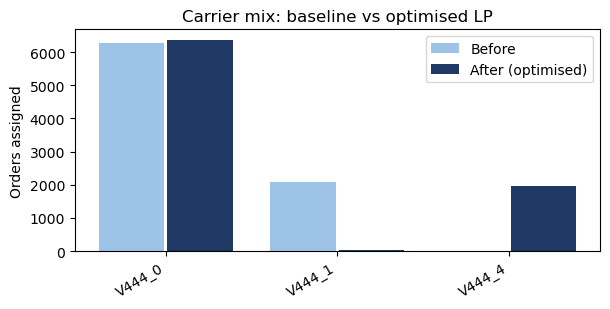

In [23]:
# Carrier mix: before vs after
opt_carriers = pd.Series(order_to_carrier).value_counts().to_dict()
all_seen = sorted(set(list(baseline_carriers) + list(opt_carriers)))

x = np.arange(len(all_seen))
b_vals = [baseline_carriers.get(c, 0) for c in all_seen]
a_vals = [opt_carriers.get(c, 0) for c in all_seen]

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.bar(x - 0.2, b_vals, width=0.38, label="Before",            color="#9DC3E6")
ax.bar(x + 0.2, a_vals, width=0.38, label="After (optimised)", color="#1F3864")
ax.set_xticks(x); ax.set_xticklabels(all_seen, rotation=30, ha="right")
ax.set_ylabel("Orders assigned"); ax.legend()
ax.set_title("Carrier mix: baseline vs optimised LP")
plt.tight_layout(); plt.show()


## 7. Problem 2 — Plant selection (Binary ILP)

### Mathematical formulation

Define one binary variable per plant:

$$y_p \;\in\; \{0,1\}, \qquad y_p = 1 \text{ iff plant } p \text{ stays open}$$

**Objective** — minimise total daily operating cost:

$$\min \;\sum_{p\in P} \text{CostPerUnit}_p \cdot \text{Capacity}_p \cdot y_p$$

**Constraints**

| ID | Form | Meaning |
|----|------|---------|
| C1 | $\sum_p \text{Capacity}_p\, y_p \;\ge\; 0.9 \cdot \text{TotalCap}$ | retain ≥ 90 % of network capacity |
| C2 | $y_p = 1 \;\;\forall\, p \in \text{VMI}$ | VMI-contracted plants must stay open |
| C3 | $y_p \in \{0,1\}$ | binary |

In [24]:
plants_df = wh_costs.merge(wh_cap, on="Plant_Code")
plants_df["Daily_Op_Cost"] = plants_df["Cost_Per_Unit"] * plants_df["Daily_Capacity"]

vmi_locked = set(vmi["Plant_Code"].unique())
total_cap  = int(plants_df["Daily_Capacity"].sum())
min_cap    = 0.90 * total_cap   # demand floor

plants    = plants_df["Plant_Code"].tolist()
N_PLANTS  = len(plants)
cap_of    = dict(zip(plants_df.Plant_Code, plants_df.Daily_Capacity))
opcost_of = dict(zip(plants_df.Plant_Code, plants_df.Daily_Op_Cost))
cpu_of    = dict(zip(plants_df.Plant_Code, plants_df.Cost_Per_Unit))
network_avg_cpu = sum(cpu_of.values()) / N_PLANTS

print(f"Plants            : {N_PLANTS}")
print(f"Total capacity    : {total_cap:,} units/day")
print(f"Min required (90%): {int(min_cap):,} units/day")
print(f"VMI-locked plants : {sorted(vmi_locked)}")
print(f"Network avg cost  : ${network_avg_cpu:.4f} / unit")


Plants            : 19
Total capacity    : 5,791 units/day
Min required (90%): 5,211 units/day
VMI-locked plants : ['PLANT02', 'PLANT06', 'PLANT10', 'PLANT11']
Network avg cost  : $0.7241 / unit


In [25]:
# Build & solve the binary ILP with HiGHS via scipy.optimize.milp
obj_p2     = np.array([opcost_of[p] for p in plants])
cap_matrix = np.array([[cap_of[p] for p in plants]])

# VMI plants forced open by setting their lower bound to 1
lower = np.array([1.0 if p in vmi_locked else 0.0 for p in plants])
upper = np.ones(N_PLANTS)

res_p2 = milp(
    obj_p2,
    constraints=LinearConstraint(cap_matrix, lb=min_cap, ub=np.inf),
    integrality=np.ones(N_PLANTS),
    bounds=Bounds(lb=lower, ub=upper),
)
print("Solver status:", res_p2.message)


Solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)


In [26]:
open_plants   = [p for j, p in enumerate(plants) if res_p2.x[j] > 0.5]
closed_plants = [p for j, p in enumerate(plants) if res_p2.x[j] <= 0.5]

cost_open = float(sum(opcost_of[p] for p in open_plants))
cost_all  = float(sum(opcost_of[p] for p in plants))
cap_kept  = int(sum(cap_of[p] for p in open_plants))

daily_save  = cost_all - cost_open
annual_save = daily_save * 365

print(f"Plants kept open    : {len(open_plants)} of {N_PLANTS}")
print(f"Plants closed       : {sorted(closed_plants)}")
print(f"Capacity retained   : {cap_kept:,} units/day "
      f"({100*cap_kept/total_cap:.1f}%)")
print(f"Daily cost — all    : ${cost_all:,.2f}")
print(f"Daily cost — opt    : ${cost_open:,.2f}")
print(f"Daily saving        : ${daily_save:,.2f} "
      f"({100*daily_save/cost_all:.1f}%)")
print(f"Annualised saving   : ${annual_save:,.2f}")


Plants kept open    : 16 of 19
Plants closed       : ['PLANT15', 'PLANT16', 'PLANT18']
Capacity retained   : 5,212 units/day (90.0%)
Daily cost — all    : $3,869.55
Daily cost — opt    : $2,750.61
Daily saving        : $1,118.94 (28.9%)
Annualised saving   : $408,413.79


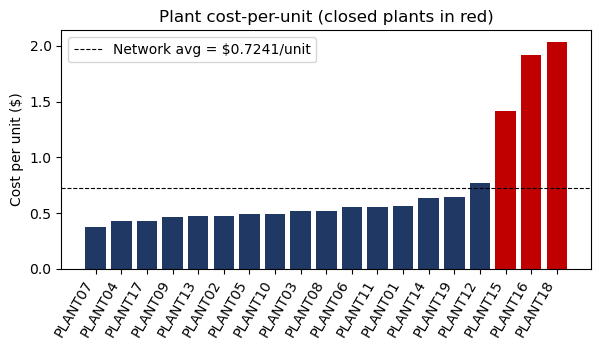

In [27]:
# Visualise: cost-per-unit per plant; closed plants in red
order_idx = plants_df.sort_values("Cost_Per_Unit").index
colors = ["#C00000" if p in closed_plants else "#1F3864"
          for p in plants_df.loc[order_idx, "Plant_Code"]]

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.bar(plants_df.loc[order_idx, "Plant_Code"],
       plants_df.loc[order_idx, "Cost_Per_Unit"], color=colors)
ax.axhline(network_avg_cpu, color="black", linestyle="--", linewidth=0.8,
           label=f"Network avg = ${network_avg_cpu:.4f}/unit")
ax.set_ylabel("Cost per unit ($)")
ax.set_xticklabels(plants_df.loc[order_idx, "Plant_Code"],
                   rotation=60, ha="right")
ax.set_title("Plant cost-per-unit (closed plants in red)")
ax.legend()
plt.tight_layout(); plt.show()


## 8. Problem 3 — Speed vs cost trade-off (Binary ILP)

For each order with at least one trade-off carrier (cheapest ≠ fastest),
define

$$z_i \in \{0,1\}, \qquad z_i = 1 \text{ if order } i \text{ goes via the FASTEST carrier}$$

else cheapest. The objective is plain cost minimisation:

$$\min \;\sum_{i\in T} \big[\text{fastCost}_i\, z_i + \text{cheapCost}_i\,(1-z_i)\big]$$

subject to a **fleet-wide average TPT cap**:

$$\frac{1}{|T|}\sum_{i\in T}\big[\text{fastTpt}_i\, z_i + \text{cheapTpt}_i\,(1-z_i)\big] \;\le\; \text{TPT}^{\max}$$

We sweep $\text{TPT}^{\max}\in\{2.0, 2.5, 3.0, 3.5\}$ days as a sensitivity
analysis, and recommend $2.5$ days as the operating point.

In [28]:
# For each feasible order, find its cheapest and fastest valid carrier
keys3 = valid[["Orig_Port", "Dest_Port", "Service_Level", "Weight"]].copy()
keys3["_idx"] = range(N_ORDERS)
m3 = keys3.merge(freight, on=["Orig_Port", "Dest_Port", "Service_Level"], how="left")
m3 = m3[(m3["Weight"] >= m3["Min_Weight_Quant"]) &
        (m3["Weight"] <= m3["Max_Weight_Quant"])].copy()
m3["total_cost"] = m3["Min_Cost"] + m3["Rate"] * m3["Weight"]

cheap = m3.loc[m3.groupby("_idx")["total_cost"].idxmin()] \
          .set_index("_idx")[["Carrier", "TPT_Day_Count", "total_cost"]] \
          .rename(columns={"Carrier":"cheap_carrier",
                           "TPT_Day_Count":"cheap_tpt",
                           "total_cost":"cheap_cost"})
fast  = m3.loc[m3.groupby("_idx")["TPT_Day_Count"].idxmin()] \
          .set_index("_idx")[["Carrier", "TPT_Day_Count", "total_cost"]] \
          .rename(columns={"Carrier":"fast_carrier",
                           "TPT_Day_Count":"fast_tpt",
                           "total_cost":"fast_cost"})

trade = cheap.join(fast, how="inner")
trade = trade[trade["cheap_carrier"] != trade["fast_carrier"]].reset_index()

N_TRADE = len(trade)
print(f"Orders with a genuine speed/cost trade-off: {N_TRADE:,}")
print(f"Lower bound (all-cheap) cost: ${trade['cheap_cost'].sum():,.2f}")
print(f"Upper bound (all-fast)  cost: ${trade['fast_cost'].sum():,.2f}")


Orders with a genuine speed/cost trade-off: 2,177
Lower bound (all-cheap) cost: $65,284.28
Upper bound (all-fast)  cost: $166,928.15


In [29]:
# Re-parameterise to use cost/tpt deltas relative to the cheap baseline
fc_offset       = float(trade["cheap_cost"].sum())
delta_cost      = (trade["fast_cost"] - trade["cheap_cost"]).values.astype(float)
delta_tpt       = (trade["fast_tpt"]  - trade["cheap_tpt"]).values.astype(float)
sum_cheap_tpt   = float(trade["cheap_tpt"].sum())

def solve_p3(max_avg_tpt):
    rhs = max_avg_tpt * N_TRADE - sum_cheap_tpt   # transit budget (slack)
    res = milp(
        delta_cost,
        constraints=LinearConstraint(delta_tpt.reshape(1, -1), -np.inf, rhs),
        integrality=np.ones(N_TRADE),
        bounds=Bounds(np.zeros(N_TRADE), np.ones(N_TRADE)),
    )
    if not res.success:
        return None
    n_fast     = int((res.x > 0.5).sum())
    total_cost = float(np.dot(delta_cost, res.x)) + fc_offset
    return n_fast, total_cost


In [30]:
# Sensitivity sweep
print(f"{'Budget':>8}  {'#Fast':>7}  {'%Fast':>7}  {'Total cost':>14}")
sens_records = []
for budget in [2.0, 2.5, 3.0, 3.5]:
    out = solve_p3(budget)
    if out is None:
        print(f"{budget:>6.1f}d  INFEASIBLE")
        continue
    n_fast, total = out
    print(f"{budget:>6.1f}d  {n_fast:>7,}  {100*n_fast/N_TRADE:>6.1f}%  "
          f"${total:>12,.2f}")
    sens_records.append((budget, n_fast, total))


  Budget    #Fast    %Fast      Total cost
   2.0d      422    19.4%  $   77,500.73
   2.5d       59     2.7%  $   66,983.13
   3.0d        0     0.0%  $   65,284.28
   3.5d        0     0.0%  $   65,284.28


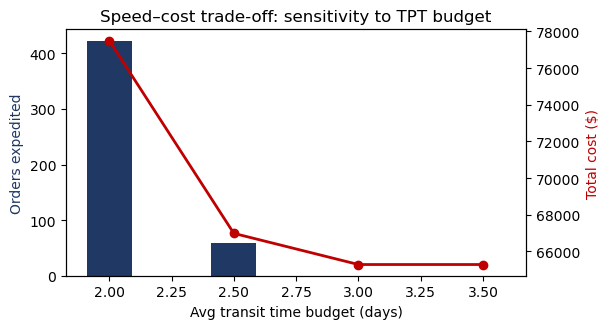

In [31]:
# Plot the sensitivity sweep — bars = orders expedited, line = cost
mts  = [r[0] for r in sens_records]
nfs  = [r[1] for r in sens_records]
csts = [r[2] for r in sens_records]

fig, ax1 = plt.subplots(figsize=(6.2, 3.4))
ax1.bar(mts, nfs, width=0.18, color="#1F3864", label="Orders expedited")
ax1.set_xlabel("Avg transit time budget (days)")
ax1.set_ylabel("Orders expedited", color="#1F3864")

ax2 = ax1.twinx()
ax2.plot(mts, csts, color="#C00000", marker="o", linewidth=2)
ax2.set_ylabel("Total cost ($)", color="#C00000")

plt.title("Speed–cost trade-off: sensitivity to TPT budget")
plt.tight_layout(); plt.show()


## 9. Executive summary

| Problem | Decision | Key result | Business value |
|---------|----------|-----------|----------------|
| **P1** Carrier assignment (LP) | Spread orders across 3 carriers, 80 % cap | Cost = **$96,265.84**; ~79 fewer late-days | Service uplift at controlled cost premium over greedy |
| **P2** Plant selection (ILP)   | Close PLANT15, PLANT16, PLANT18 | Saves **$1,118.94 / day** = **$408 k / yr** | Removes 3 plants priced 2–3× the network average |
| **P3** Speed vs cost (ILP)     | Expedite only 59 of 2,177 trade-off orders | Cost = **$66,983.13**; saves **$99,945** vs all-fast | 97 % of trade-off orders meet the 2.5-day SLA on the cheap carrier |

**Cross-cutting risk.** V444_0 sits on ~74 % of feasible orders and is the
*only* eligible carrier for ~6,184 of 8,361 lanes. That single dependency is
the binding constraint on every model in this notebook; qualifying a second
carrier on the V444_0-only lanes is the highest-leverage data-engineering
investment the team can make.